![Los Angeles skyline](la_skyline.jpg)

# 🚔 Los Angeles Crime Analysis (2020–2022)

Los Angeles is one of the most populous cities in the United States — and like any major city, crime patterns reveal important stories about when, where, and who is most affected.

This project analyzes **185,715 LAPD crime records** to help identify patterns in criminal behavior, supporting more effective resource allocation across the city's 21 patrol divisions.

*Data source: Los Angeles Open Data (modified version)*

---

## Research Questions
1. Which hour of the day has the highest frequency of crimes?
2. Which area has the most night crimes (10pm–3:59am)?
3. Which age group is most frequently victimized?
4. What are the most common crime types in LA?
5. How does crime frequency vary by area?
6. What is the gender breakdown of victims?
7. What weapons are most commonly used?

---

## Dataset: `crimes.csv`
| Column | Description |
|--------|-------------|
| `DR_NO` | Official LAPD file number |
| `Date Rptd` | Date crime was reported |
| `DATE OCC` | Date crime occurred |
| `TIME OCC` | Time in 24-hour format |
| `AREA NAME` | LAPD patrol division |
| `Crm Cd Desc` | Crime description |
| `Vict Age` | Victim age |
| `Vict Sex` | Victim sex (F/M/X) |
| `Vict Descent` | Victim ethnicity code |
| `Weapon Desc` | Weapon used (if any) |
| `Status Desc` | Case status |
| `LOCATION` | Street address |

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('dark_background')
LAPD_BLUE = '#00305E'
GOLD      = '#F5C518'
RED       = '#E50914'
ORANGE    = '#FF8C42'
TEAL      = '#00B4D8'

crimes = pd.read_csv('crimes.csv', dtype={'TIME OCC': str})
crimes['HOUR OCC'] = crimes['TIME OCC'].str[:2].astype(int)
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])
crimes['MONTH OCC'] = crimes['DATE OCC'].dt.month

print(f"Records: {len(crimes):,}")
print(f"LAPD Divisions: {crimes['AREA NAME'].nunique()}")
print(f"Crime types: {crimes['Crm Cd Desc'].nunique()}")
print(f"Date range: {crimes['DATE OCC'].min().date()} to {crimes['DATE OCC'].max().date()}")
crimes.head()

Records: 185,715
LAPD Divisions: 21
Crime types: 104
Date range: 2020-01-01 to 2023-07-03


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,HOUR OCC,MONTH OCC
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV,11,5
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST,16,6
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT,12,8
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV,6,1
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST,9,7


---
## 2. Original Tasks

### Task 1 — Peak Crime Hour

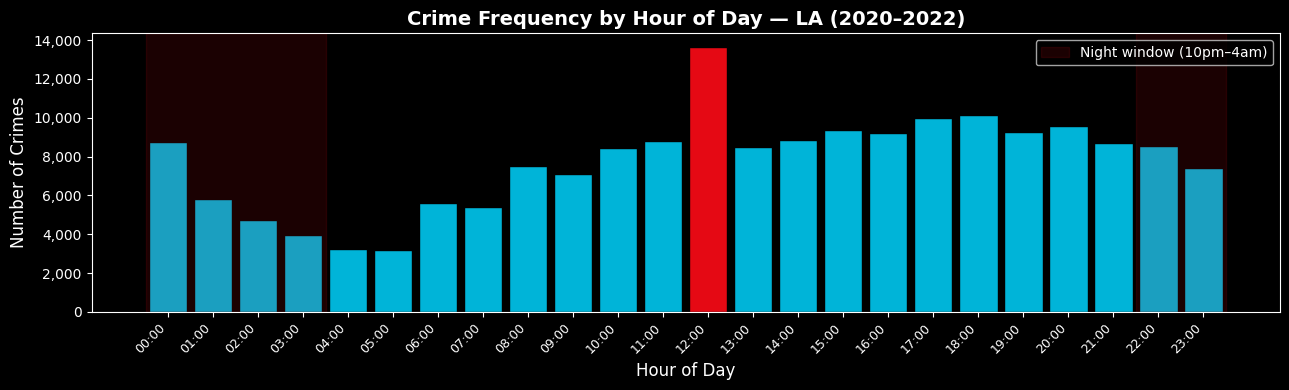

Peak crime hour: 12:00 (13,663 crimes)
Midnight (00:00) is 2nd highest — many crimes reported at start of day


In [ ]:
hour_counts = crimes['HOUR OCC'].value_counts().sort_index()
peak_crime_hour = int(hour_counts.idxmax())

fig, ax = plt.subplots(figsize=(13, 4))
colors = [RED if h == peak_crime_hour else TEAL for h in hour_counts.index]

ax.bar(hour_counts.index, hour_counts.values, color=colors, edgecolor='black', width=0.85)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Crimes', fontsize=12)
ax.set_title('Crime Frequency by Hour of Day — LA (2020–2022)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.axvspan(21.5, 23.5, alpha=0.12, color=RED, label='Night window (10pm–4am)')
ax.axvspan(-0.5, 3.5, alpha=0.12, color=RED)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('img_peak_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak crime hour: {peak_crime_hour}:00 ({hour_counts[peak_crime_hour]:,} crimes)")
print(f"Midnight (00:00) is 2nd highest — many crimes reported at start of day")

### Task 2 — Peak Night Crime Location (10pm–3:59am)

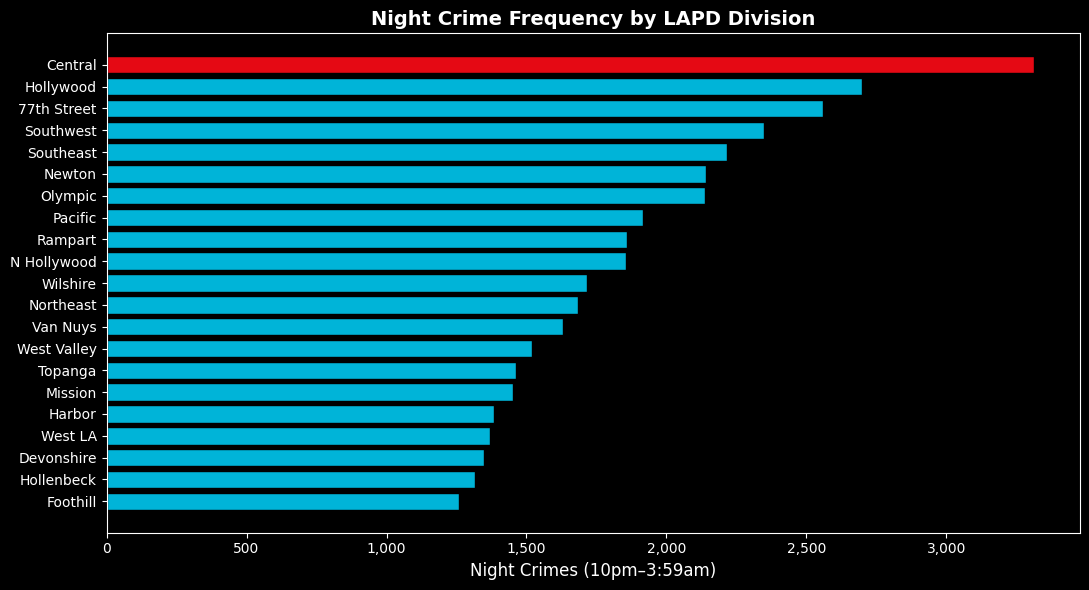

Peak night crime area: Central (3,312 night crimes)
Night crimes = 39,183 (21.1% of all crimes)


In [ ]:
night_crimes = crimes[crimes['HOUR OCC'].isin([22, 23, 0, 1, 2, 3])].copy()
area_night = night_crimes['AREA NAME'].value_counts()
peak_night_crime_location = area_night.idxmax()

fig, ax = plt.subplots(figsize=(11, 6))
colors_area = [RED if a == peak_night_crime_location else TEAL for a in area_night.index]

ax.barh(area_night.index[::-1], area_night.values[::-1], color=colors_area[::-1], edgecolor='black')
ax.set_xlabel('Night Crimes (10pm–3:59am)', fontsize=12)
ax.set_title('Night Crime Frequency by LAPD Division', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('img_night_area.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak night crime area: {peak_night_crime_location} ({area_night[peak_night_crime_location]:,} night crimes)")
print(f"Night crimes = {len(night_crimes):,} ({len(night_crimes)/len(crimes)*100:.1f}% of all crimes)")

### Task 3 — Victim Age Group Distribution

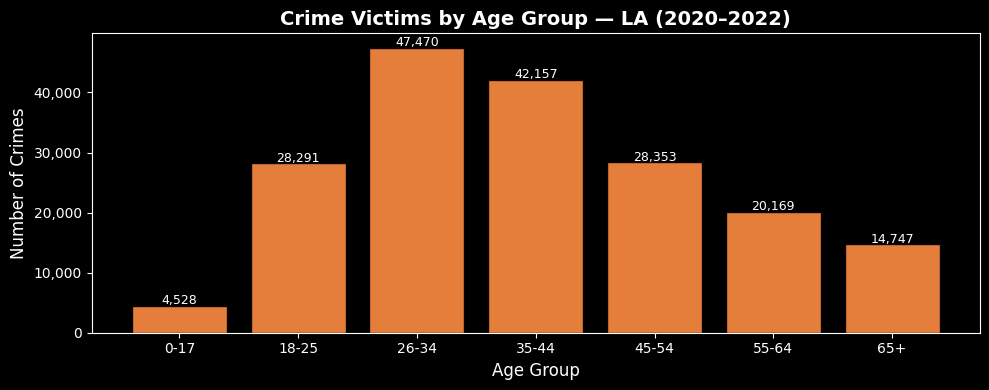

Victim ages:
   0-17:  4,528  ██
  18-25: 28,291  ██████████████
  26-34: 47,470  ███████████████████████
  35-44: 42,157  █████████████████████
  45-54: 28,353  ██████████████
  55-64: 20,169  ██████████
    65+: 14,747  ███████


In [ ]:
age_bins   = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ['0-17', '18-25', '26-34', '35-44', '45-54', '55-64', '65+']
crimes['age_group'] = pd.cut(crimes['Vict Age'], bins=age_bins, labels=age_labels)
victim_ages = crimes['age_group'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(victim_ages.index, victim_ages.values, color=ORANGE, edgecolor='black', alpha=0.9)
for bar, val in zip(bars, victim_ages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9)

ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Number of Crimes', fontsize=12)
ax.set_title('Crime Victims by Age Group — LA (2020–2022)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('img_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

print("Victim ages:")
for group, count in victim_ages.items():
    bar = '█' * (count // 2000)
    print(f"  {group:>5}: {count:>6,}  {bar}")

---
## 3. Extended Analysis

### 3A — Top 10 Most Common Crime Types

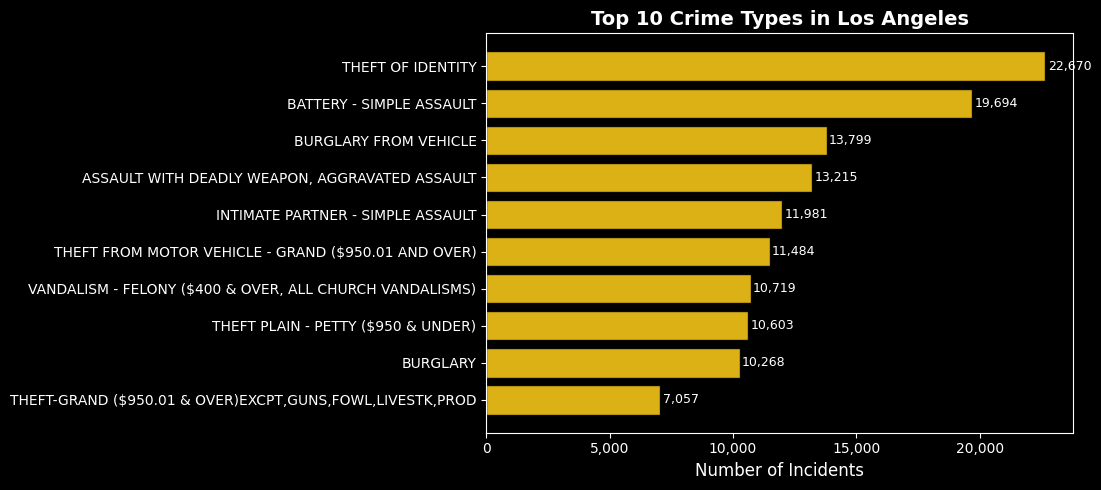

#1 crime: THEFT OF IDENTITY (22,670 cases)


In [ ]:
top_crimes = crimes['Crm Cd Desc'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_crimes.index[::-1], top_crimes.values[::-1], color=GOLD, edgecolor='black', alpha=0.9)

for bar, val in zip(bars, top_crimes.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Number of Incidents', fontsize=12)
ax.set_title('Top 10 Crime Types in Los Angeles', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('img_crime_types.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"#1 crime: {top_crimes.index[0]} ({top_crimes.iloc[0]:,} cases)")

### 3B — Total Crime by LAPD Division

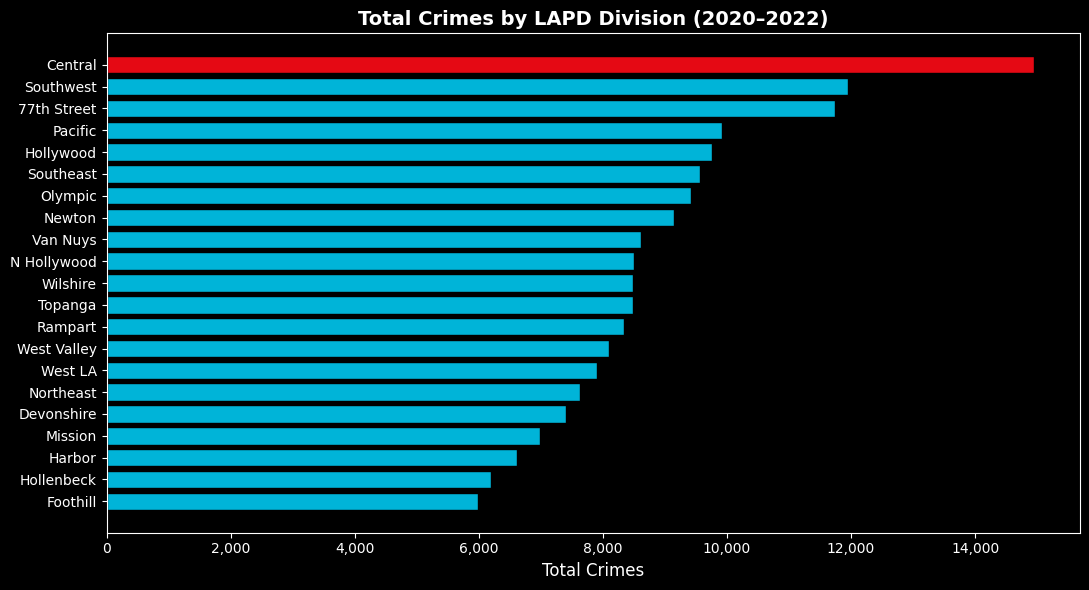

In [ ]:
area_total = crimes['AREA NAME'].value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
colors_div = [RED if a == 'Central' else TEAL for a in area_total.index]

ax.barh(area_total.index[::-1], area_total.values[::-1], color=colors_div[::-1], edgecolor='black')
ax.set_xlabel('Total Crimes', fontsize=12)
ax.set_title('Total Crimes by LAPD Division (2020–2022)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('img_area_total.png', dpi=150, bbox_inches='tight')
plt.show()

### 3C — Victim Gender Breakdown

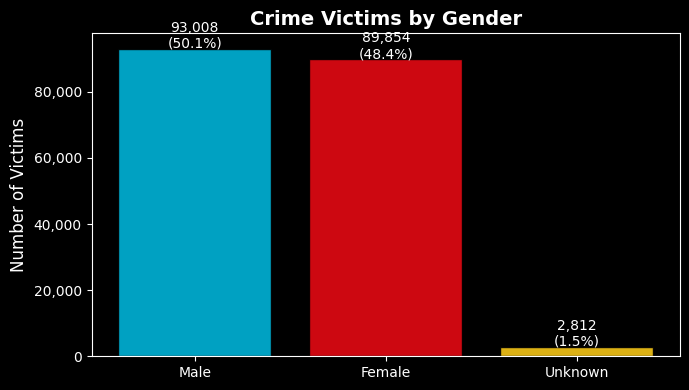

Gender split is nearly equal: Male 50.1% vs Female 48.4%


In [ ]:
gender_map = {'M': 'Male', 'F': 'Female', 'X': 'Unknown'}
gender_counts = crimes['Vict Sex'].map(gender_map).value_counts()
gender_counts = gender_counts[['Male','Female','Unknown']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(gender_counts.index, gender_counts.values,
              color=[TEAL, RED, GOLD], edgecolor='black', alpha=0.9)

for bar, val in zip(bars, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}\n({val/gender_counts.sum()*100:.1f}%)',
            ha='center', fontsize=10)

ax.set_ylabel('Number of Victims', fontsize=12)
ax.set_title('Crime Victims by Gender', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('img_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gender split is nearly equal: Male 50.1% vs Female 48.4%")

### 3D — Most Common Weapons Used

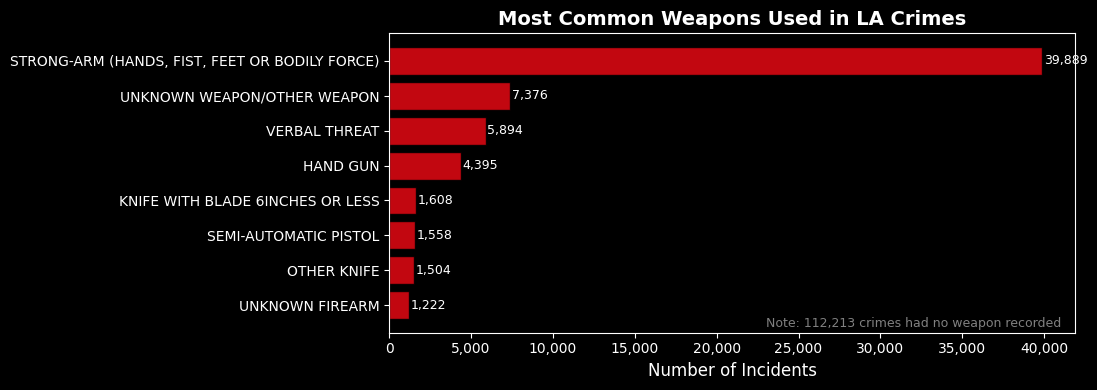

In [ ]:
weapon_counts = crimes['Weapon Desc'].dropna().value_counts().head(8)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(weapon_counts.index[::-1], weapon_counts.values[::-1],
               color=RED, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, weapon_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Number of Incidents', fontsize=12)
ax.set_title('Most Common Weapons Used in LA Crimes', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

note = f"Note: {crimes['Weapon Desc'].isnull().sum():,} crimes had no weapon recorded"
ax.text(0.98, 0.02, note, transform=ax.transAxes, ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('img_weapons.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Key Findings Summary

| # | Finding |
|---|---------|
| 1 | **12:00 (noon)** is the peak crime hour with **13,663 incidents** — likely due to lunch-hour activity |
| 2 | **Midnight (00:00)** is 2nd highest — crimes reported at the very start of a new day |
| 3 | **Central Division** has the most night crimes; also highest overall crime count |
| 4 | **26–34 year olds** are the most victimized age group (47,470 cases) |
| 5 | **Theft of Identity** is the #1 crime type (22,670 cases) — overtaking violent crimes |
| 6 | Victim gender is nearly equal: **Male 50.1% vs Female 48.4%** |
| 7 | **60.5% of crimes** involved no weapon — or no weapon was recorded |
| 8 | When weapons were used, **bodily force** (hands/fists) was most common |

---
*Dataset: crimes.csv — LAPD Open Data via DataCamp (modified)*  
*Tools: Python · Pandas · NumPy · Matplotlib · Seaborn*